In [233]:
# Import foundation
import os, signal, sys, time

sys.path.append(r'C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-')

from ai_economist import foundation

In [234]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from IPython import display
from utils import plotting  # plotting utilities for visualizing env. state

In [235]:
env_config = {
    # ===== SCENARIO CLASS =====
    'scenario_name': 'layout_from_file/simple_wood_and_stone',

    # ===== COMPONENTS =====
    'components': [
        # (1) Building houses (REQUIRES payment when using fixed_four_skill_and_loc=True)
        ('Build', {
            'payment': 10.0,                    # <-- REQUIRED for LayoutFromFile fixed_four_skill_and_loc
            'skill_dist': "pareto",             # <-- REQUIRED
            'payment_max_skill_multiplier': 3   # good
        }),
        # (2) Trading collectible resources
        ('ContinuousDoubleAuction', {'max_num_orders': 5}),
        # (3) Movement and resource collection
        ('Gather', {}),
    ],

    # ===== SCENARIO CLASS ARGUMENTS =====
    'env_layout_file': 'quadrant_25x25_20each_30clump.txt',
    'starting_agent_coin': 10,
    'fixed_four_skill_and_loc': True,  # <-- works only if Build.payment is set as above

    # ===== STANDARD ARGUMENTS ======
    'n_agents': 4,
    'world_size': [25, 25],
    'episode_length': 1000,

    # multi-action mode (optional; leaving your choices)
    'multi_action_mode_agents': False,
    'multi_action_mode_planner': True,

    # flattening options (fine as-is)
    'flatten_observations': False,
    'flatten_masks': True,
}

In [236]:
# Define the configuration of the environment that will be built

env_config_planner = {
    # ===== SCENARIO CLASS =====
    # Which Scenario class to use: the class's name in the Scenario Registry (foundation.scenarios).
    # The environment object will be an instance of the Scenario class.
    'scenario_name': 'layout_from_file/simple_wood_and_stone',
    
    # ===== COMPONENTS =====
    # Which components to use (specified as list of ("component_name", {component_kwargs}) tuples).
    #     "component_name" refers to the Component class's name in the Component Registry (foundation.components)
    #     {component_kwargs} is a dictionary of kwargs passed to the Component class
    # The order in which components reset, step, and generate obs follows their listed order below.


    'components': [
        # (1) Building houses
        # OLD: 
        ('Build', dict(skill_dist="pareto", payment_max_skill_multiplier=3)),
        # ('Build', {
        #     'payment': 10.0,                    # <-- REQUIRED for LayoutFromFile fixed_four_skill_and_loc
        #     'skill_dist': "pareto",             # <-- REQUIRED
        #     'payment_max_skill_multiplier': 3   # good
        # }),
        # (2) Trading collectible resources
        ('ContinuousDoubleAuction', dict(max_num_orders=5)),
        # (3) Movement and resource collection
        ('Gather', dict()),
        # (4) Income tax & lump-sum redistribution
        ('PeriodicBracketTax', dict(bracket_spacing="us-federal", period=10)) #set period=100 when running real sim
    ],
    
    # ===== SCENARIO CLASS ARGUMENTS =====
    # (optional) kwargs that are added by the Scenario class (i.e. not defined in BaseEnvironment)
    'env_layout_file': "quadrant_25x25_20each_30clump.txt",
    'starting_agent_coin': 10,
    'fixed_four_skill_and_loc': True,
    
    # ===== STANDARD ARGUMENTS ======
    # kwargs that are used by every Scenario class (i.e. defined in BaseEnvironment)
    'n_agents': 4,          # Number of non-planner agents (must be >1)
    'world_size': [25, 25], # [Height, Width] of the env world
    'episode_length': 100, # Number of timesteps per episode (UPDATED)
    
    # In multi-action-mode, the policy selects an action for each action subspace (defined in component code).
    # Otherwise, the policy selects only 1 action.
    'multi_action_mode_agents': False,
    'multi_action_mode_planner': True,
    
    # When flattening observations, concatenate scalar & vector observations before output.
    # Otherwise, return observations with minimal processing.
    'flatten_observations': False,
    # When Flattening masks, concatenate each action subspace mask into a single array.
    # Note: flatten_masks = True is required for masking action logits in the code below.
    'flatten_masks': False, #this is set for dimentions to match 
}

In [237]:
env_p = foundation.make_env_instance(**env_config_planner)
obs = env_p.reset()

In [238]:
env_p.world.planner.action_dim

{'PeriodicBracketTax.TaxIndexBracket_000': 22,
 'PeriodicBracketTax.TaxIndexBracket_009': 22,
 'PeriodicBracketTax.TaxIndexBracket_039': 22,
 'PeriodicBracketTax.TaxIndexBracket_084': 22,
 'PeriodicBracketTax.TaxIndexBracket_160': 22,
 'PeriodicBracketTax.TaxIndexBracket_204': 22,
 'PeriodicBracketTax.TaxIndexBracket_510': 22}

In [239]:
import numpy as np

def _normalize_mask(m):
    """Convert list/array mask into probability vector."""
    m = np.asarray(m, dtype=float)
    s = m.sum()
    if s <= 0 or not np.isfinite(s):
        return np.ones_like(m) / len(m)
    return m / s

def sample_random_action(agent, mask):
    """
    Correct sampler for:
      - multi-action planner (mask dict)
      - multi-mask workers (mask list of arrays)
      - simple-mask workers (1D array)
    """
    # --- CASE A: multi-action planner (dict of masks) ---
    if isinstance(mask, dict):
        actions = []
        for subspace_name, sub_mask in mask.items():
            probs = _normalize_mask(sub_mask)
            n = agent.action_dim[subspace_name]
            if len(probs) != n:
                probs = np.ones(n) / n
            actions.append(int(np.random.choice(n, p=probs)))
        return actions

    # --- CASE B: worker mask is a LIST of mask arrays (multi-component env) ---
    if isinstance(mask, list):
        # Flatten into one big mask of length agent._unique_actions
        flat = np.concatenate([np.asarray(m, dtype=float) for m in mask])
        probs = _normalize_mask(flat)
        n = agent._unique_actions
        if len(probs) != n:
            probs = np.ones(n) / n
        return int(np.random.choice(n, p=probs))

    # --- CASE C: worker mask is a simple array ---
    if mask is None:
        return 0
    probs = _normalize_mask(mask)
    return int(np.random.choice(len(probs), p=probs))


def sample_random_actions(env, obs):
    actions = {}
    for a_idx, a_obs in obs.items():
        if a_idx not in env._agent_lookup:
            continue
        agent = env.get_agent(a_idx)
        mask = a_obs.get("action_mask")
        actions[a_idx] = sample_random_action(agent, mask)
    return actions

In [240]:
from ai_economist import foundation
import numpy as np


done = {"__all__": False}

# --- Run a full episode ---
while not done["__all__"]:

    actions = {}

    # --- Worker actions (NO-OP = 0 for now) ---
    for a in env_p.world.agents:
        actions[str(a.idx)] = 0

    # --- Planner actions (multi-action mode) ---
    planner = env_p.world.planner
    p_id = planner.idx

    if planner.multi_action_mode:
        # Number of tax brackets (action subspaces)
        n_brackets = len(planner.action_dim)

        # Choose some NON-zero actions here (1..n_disc_rates)
        # Example: choose the middle tax index for all brackets
        actions[p_id] = [1] * n_brackets     # <-- planner is now active
    else:
        actions[p_id] = 0

    # --- Step environment ---
    obs, rew, done, info = env_p.step(actions)

In [241]:
p = env_p.world.planner
print("Planner action_dim:", p.action_dim)                  # dict of 7 -> 22
print("Example planner mask type:", type(obs[p.idx]["action_mask"]))
if isinstance(obs[p.idx]["action_mask"], dict):
    for k,v in obs[p.idx]["action_mask"].items():
        print(" ", k, type(v), len(v), "sum", np.asarray(v).sum())

Planner action_dim: {'PeriodicBracketTax.TaxIndexBracket_000': 22, 'PeriodicBracketTax.TaxIndexBracket_009': 22, 'PeriodicBracketTax.TaxIndexBracket_039': 22, 'PeriodicBracketTax.TaxIndexBracket_084': 22, 'PeriodicBracketTax.TaxIndexBracket_160': 22, 'PeriodicBracketTax.TaxIndexBracket_204': 22, 'PeriodicBracketTax.TaxIndexBracket_510': 22}
Example planner mask type: <class 'dict'>
  PeriodicBracketTax.TaxIndexBracket_000 <class 'list'> 21 sum 21
  PeriodicBracketTax.TaxIndexBracket_009 <class 'list'> 21 sum 21
  PeriodicBracketTax.TaxIndexBracket_039 <class 'list'> 21 sum 21
  PeriodicBracketTax.TaxIndexBracket_084 <class 'list'> 21 sum 21
  PeriodicBracketTax.TaxIndexBracket_160 <class 'list'> 21 sum 21
  PeriodicBracketTax.TaxIndexBracket_204 <class 'list'> 21 sum 21
  PeriodicBracketTax.TaxIndexBracket_510 <class 'list'> 21 sum 21


In [242]:
planner = env_p.get_agent(agent_idx='p') # The planner agent
planner.action_dim

{'PeriodicBracketTax.TaxIndexBracket_000': 22,
 'PeriodicBracketTax.TaxIndexBracket_009': 22,
 'PeriodicBracketTax.TaxIndexBracket_039': 22,
 'PeriodicBracketTax.TaxIndexBracket_084': 22,
 'PeriodicBracketTax.TaxIndexBracket_160': 22,
 'PeriodicBracketTax.TaxIndexBracket_204': 22,
 'PeriodicBracketTax.TaxIndexBracket_510': 22}

In [243]:
metrics = env_p.get_current_optimization_metrics()
metrics

{0: np.float64(6.3486189007219345),
 1: np.float64(5.9286189007219345),
 2: np.float64(6.1386189007219345),
 3: np.float64(6.3486189007219345),
 'p': np.float64(10.0)}

In [244]:
print("timestep =", env_p.world.timestep)

timestep = 100


In [245]:
from ai_economist import foundation

num_episodes = 100          # total number of episodes to run
print_every = 10            # print metrics every N episodes

for ep in range(1, num_episodes + 1):

    # --- create fresh env ---
    env = foundation.make_env_instance(**env_config_planner)
    obs = env.reset()

    done = {"__all__": False}

    # --- run episode (NO-OP policy, replace if you have agents) ---
    while not done["__all__"]:
        actions = {}

        # worker actions (0 = no-op)
        for a in env.world.agents:
            actions[str(a.idx)] = 0

        # planner action (multi-action → list of zeros)
        if env.world.planner.multi_action_mode:
            n = len(env.world.planner.action_dim)
            actions[env.world.planner.idx] = [0] * n
        else:
            actions[env.world.planner.idx] = 0

        obs, rew, done, info = env.step(actions)

    # --- END OF EPISODE: compute metrics ---
    metrics = env.get_current_optimization_metrics()

    # --- PRINT EVERY 100 EPISODES ---
    if ep % print_every == 0:
        print(f"\n=== Episode {ep} ===")
        for agent_id, val in metrics.items():
            print(f"Agent {agent_id}: {val}")


=== Episode 10 ===
Agent 0: 6.3486189007219345
Agent 1: 5.9286189007219345
Agent 2: 6.1386189007219345
Agent 3: 6.3486189007219345
Agent p: 10.0

=== Episode 20 ===
Agent 0: 5.9286189007219345
Agent 1: 6.3486189007219345
Agent 2: 6.3486189007219345
Agent 3: 6.1386189007219345
Agent p: 10.0

=== Episode 30 ===
Agent 0: 6.3486189007219345
Agent 1: 5.9286189007219345
Agent 2: 6.3486189007219345
Agent 3: 5.718618900721935
Agent p: 10.0

=== Episode 40 ===
Agent 0: 5.718618900721935
Agent 1: 6.3486189007219345
Agent 2: 6.1386189007219345
Agent 3: 6.3486189007219345
Agent p: 10.0

=== Episode 50 ===
Agent 0: 6.1386189007219345
Agent 1: 6.3486189007219345
Agent 2: 6.3486189007219345
Agent 3: 5.9286189007219345
Agent p: 10.0

=== Episode 60 ===
Agent 0: 6.3486189007219345
Agent 1: 6.3486189007219345
Agent 2: 6.1386189007219345
Agent 3: 5.9286189007219345
Agent p: 10.0

=== Episode 70 ===
Agent 0: 6.1386189007219345
Agent 1: 6.3486189007219345
Agent 2: 5.718618900721935
Agent 3: 6.348618900721

In [246]:
# Grab the tax component and call its metrics method
tax_comp = env_p.get_component("PeriodicBracketTax")   # name of the component class
tax_metrics_now = tax_comp.get_metrics()
tax_metrics_now

{'avg_bracket_rate/000': np.float64(0.0),
 'bracket_occupancy/000': np.float64(1.0),
 'avg_bracket_rate/009': np.float64(0.0),
 'bracket_occupancy/009': np.float64(0.0),
 'avg_bracket_rate/039': np.float64(0.0),
 'bracket_occupancy/039': np.float64(0.0),
 'avg_bracket_rate/084': np.float64(0.0),
 'bracket_occupancy/084': np.float64(0.0),
 'avg_bracket_rate/160': np.float64(0.0),
 'bracket_occupancy/160': np.float64(0.0),
 'avg_bracket_rate/204': np.float64(0.0),
 'bracket_occupancy/204': np.float64(0.0),
 'avg_bracket_rate/510': np.float64(0.0),
 'bracket_occupancy/510': np.float64(0.0),
 'avg_effective_tax_rate': np.float64(0.0),
 'total_collected_taxes': 0.0,
 'avg_tax_rate/poorest': np.float64(0.0),
 'avg_tax_rate/richest': np.float64(0.0)}

In [247]:
env = foundation.make_env_instance(**env_config_planner)
obs = env.reset()

In [248]:
from ai_economist import foundation

num_episodes = 100
print_every = 10

for ep in range(1, num_episodes + 1):
    env = foundation.make_env_instance(**env_config_planner)
    obs = env.reset()

    done = {"__all__": False}
    while not done["__all__"]:
        actions = {}

        # Workers: NO-OP (0). Replace with your policy if you have one.
        for a in env.world.agents:
            actions[str(a.idx)] = 0

        # Planner: multi-action → list of zeros; otherwise 0
        p = env.world.planner
        if p.multi_action_mode:
            actions[p.idx] = [0] * len(p.action_dim)
        else:
            actions[p.idx] = 0

        obs, rew, done, info = env.step(actions)

    # At the end of the episode, get tax metrics
    tax_comp = env.get_component("PeriodicBracketTax")
    tax_metrics = tax_comp.get_metrics()

    if ep % print_every == 0:
        print(f"\n=== Episode {ep} — PeriodicBracketTax.get_metrics() ===")
        for k, v in tax_metrics.items():
            print(f"{k}: {v}")


=== Episode 10 — PeriodicBracketTax.get_metrics() ===
avg_bracket_rate/000: 0.0
bracket_occupancy/000: 1.0
avg_bracket_rate/009: 0.0
bracket_occupancy/009: 0.0
avg_bracket_rate/039: 0.0
bracket_occupancy/039: 0.0
avg_bracket_rate/084: 0.0
bracket_occupancy/084: 0.0
avg_bracket_rate/160: 0.0
bracket_occupancy/160: 0.0
avg_bracket_rate/204: 0.0
bracket_occupancy/204: 0.0
avg_bracket_rate/510: 0.0
bracket_occupancy/510: 0.0
avg_effective_tax_rate: 0.0
total_collected_taxes: 0.0
avg_tax_rate/poorest: 0.0
avg_tax_rate/richest: 0.0

=== Episode 20 — PeriodicBracketTax.get_metrics() ===
avg_bracket_rate/000: 0.0
bracket_occupancy/000: 1.0
avg_bracket_rate/009: 0.0
bracket_occupancy/009: 0.0
avg_bracket_rate/039: 0.0
bracket_occupancy/039: 0.0
avg_bracket_rate/084: 0.0
bracket_occupancy/084: 0.0
avg_bracket_rate/160: 0.0
bracket_occupancy/160: 0.0
avg_bracket_rate/204: 0.0
bracket_occupancy/204: 0.0
avg_bracket_rate/510: 0.0
bracket_occupancy/510: 0.0
avg_effective_tax_rate: 0.0
total_collect

In [249]:
print("t =", env.world.timestep,
      "tax_cycle_pos =", env.get_component("PeriodicBracketTax").tax_cycle_pos, 
      "planner_action =", actions[p_id])

t = 100 tax_cycle_pos = 1 planner_action = [0, 0, 0, 0, 0, 0, 0]


In [250]:
tax_comp = env.get_component("PeriodicBracketTax")
print(tax_comp.get_metrics())

{'avg_bracket_rate/000': np.float64(0.0), 'bracket_occupancy/000': np.float64(1.0), 'avg_bracket_rate/009': np.float64(0.0), 'bracket_occupancy/009': np.float64(0.0), 'avg_bracket_rate/039': np.float64(0.0), 'bracket_occupancy/039': np.float64(0.0), 'avg_bracket_rate/084': np.float64(0.0), 'bracket_occupancy/084': np.float64(0.0), 'avg_bracket_rate/160': np.float64(0.0), 'bracket_occupancy/160': np.float64(0.0), 'avg_bracket_rate/204': np.float64(0.0), 'bracket_occupancy/204': np.float64(0.0), 'avg_bracket_rate/510': np.float64(0.0), 'bracket_occupancy/510': np.float64(0.0), 'avg_effective_tax_rate': np.float64(0.0), 'total_collected_taxes': 0.0, 'avg_tax_rate/poorest': np.float64(0.0), 'avg_tax_rate/richest': np.float64(0.0)}


In [251]:
for ep in range(100):

    env = foundation.make_env_instance(**env_config_planner)
    obs = env.reset()
    done = {"__all__": False}

    while not done["__all__"]:

        actions = {}

        for a in env.world.agents:
            actions[str(a.idx)] = 0

        planner = env.world.planner
        n_brackets = len(planner.action_dim)
        actions[planner.idx] = [1] * n_brackets   # or random, or your policy

        obs, rew, done, info = env.step(actions)

    print("EP", ep, "TAX METRICS:", env.get_component("PeriodicBracketTax").get_metrics())

EP 0 TAX METRICS: {'avg_bracket_rate/000': np.float64(0.0), 'bracket_occupancy/000': np.float64(1.0), 'avg_bracket_rate/009': np.float64(0.0), 'bracket_occupancy/009': np.float64(0.0), 'avg_bracket_rate/039': np.float64(0.0), 'bracket_occupancy/039': np.float64(0.0), 'avg_bracket_rate/084': np.float64(0.0), 'bracket_occupancy/084': np.float64(0.0), 'avg_bracket_rate/160': np.float64(0.0), 'bracket_occupancy/160': np.float64(0.0), 'avg_bracket_rate/204': np.float64(0.0), 'bracket_occupancy/204': np.float64(0.0), 'avg_bracket_rate/510': np.float64(0.0), 'bracket_occupancy/510': np.float64(0.0), 'avg_effective_tax_rate': np.float64(0.0), 'total_collected_taxes': 0.0, 'avg_tax_rate/poorest': np.float64(0.0), 'avg_tax_rate/richest': np.float64(0.0)}
EP 1 TAX METRICS: {'avg_bracket_rate/000': np.float64(0.0), 'bracket_occupancy/000': np.float64(1.0), 'avg_bracket_rate/009': np.float64(0.0), 'bracket_occupancy/009': np.float64(0.0), 'avg_bracket_rate/039': np.float64(0.0), 'bracket_occupancy/

In [252]:
import pandas as pd

num_episodes = 30
rows = []

for ep in range(1, num_episodes + 1):
    env = foundation.make_env_instance(**env_config_planner)
    obs = env.reset()

    done = {"__all__": False}
    while not done["__all__"]:
        actions = {}
        for a in env.world.agents:
            actions[str(a.idx)] = 0
        p = env.world.planner
        actions[p.idx] = [0] * len(p.action_dim) if p.multi_action_mode else 0
        obs, rew, done, info = env.step(actions)

    tax_comp = env.get_component("PeriodicBracketTax")
    m = tax_comp.get_metrics()
    m_row = {"episode": ep}
    m_row.update(m)
    rows.append(m_row)

df_tax = pd.DataFrame(rows)
df_tax.head()

,episode,avg_bracket_rate/000,bracket_occupancy/000,avg_bracket_rate/009,bracket_occupancy/009,avg_bracket_rate/039,bracket_occupancy/039,avg_bracket_rate/084,bracket_occupancy/084,avg_bracket_rate/160,bracket_occupancy/160,avg_bracket_rate/204,bracket_occupancy/204,avg_bracket_rate/510,bracket_occupancy/510,avg_effective_tax_rate,total_collected_taxes,avg_tax_rate/poorest,avg_tax_rate/richest
0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [253]:
episode_tax_log = []

env = foundation.make_env_instance(**env_config_planner)
obs = env.reset()
tax_comp = env.get_component("PeriodicBracketTax")

done = {"__all__": False}
while not done["__all__"]:
    actions = {}
    for a in env.world.agents:
        actions[str(a.idx)] = 0
    p = env.world.planner
    actions[p.idx] = [0] * len(p.action_dim) if p.multi_action_mode else 0

    obs, rew, done, info = env.step(actions)

    # OPTIONAL: log metrics, e.g., at tax days or every K steps
    if tax_comp.tax_cycle_pos == 1 or done["__all__"]:
        episode_tax_log.append({
            "t": env.world.timestep,
            **tax_comp.get_metrics()
        })

episode_tax_log[:3]

[{'t': 10,
  'avg_bracket_rate/000': np.float64(0.0),
  'bracket_occupancy/000': np.float64(1.0),
  'avg_bracket_rate/009': np.float64(0.0),
  'bracket_occupancy/009': np.float64(0.0),
  'avg_bracket_rate/039': np.float64(0.0),
  'bracket_occupancy/039': np.float64(0.0),
  'avg_bracket_rate/084': np.float64(0.0),
  'bracket_occupancy/084': np.float64(0.0),
  'avg_bracket_rate/160': np.float64(0.0),
  'bracket_occupancy/160': np.float64(0.0),
  'avg_bracket_rate/204': np.float64(0.0),
  'bracket_occupancy/204': np.float64(0.0),
  'avg_bracket_rate/510': np.float64(0.0),
  'bracket_occupancy/510': np.float64(0.0),
  'avg_effective_tax_rate': np.float64(0.0),
  'total_collected_taxes': 0.0,
  'avg_tax_rate/poorest': np.float64(0.0),
  'avg_tax_rate/richest': np.float64(0.0)},
 {'t': 20,
  'avg_bracket_rate/000': np.float64(0.0),
  'bracket_occupancy/000': np.float64(1.0),
  'avg_bracket_rate/009': np.float64(0.0),
  'bracket_occupancy/009': np.float64(0.0),
  'avg_bracket_rate/039': np.fl

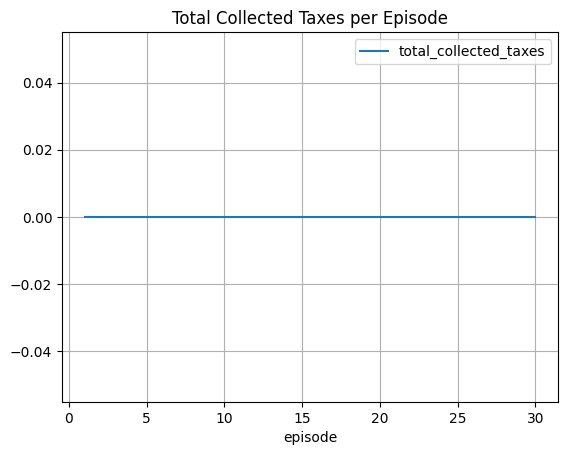

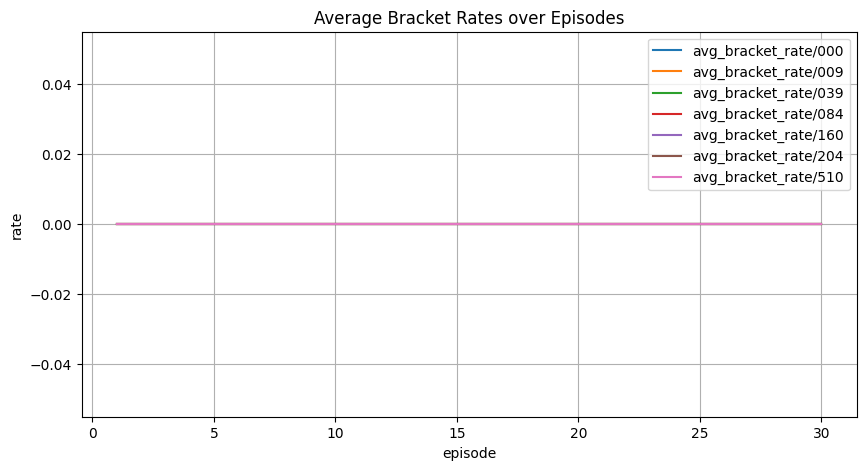

In [254]:
import matplotlib.pyplot as plt

# Example: plot total_collected_taxes across episodes
if "total_collected_taxes" in df_tax.columns:
    df_tax.plot(x="episode", y="total_collected_taxes", title="Total Collected Taxes per Episode", grid=True)

# Example: bracket rates (if present)
br_cols = [c for c in df_tax.columns if c.startswith("avg_bracket_rate/")]
if br_cols:
    plt.figure(figsize=(10,5))
    for c in br_cols:
        plt.plot(df_tax["episode"], df_tax[c], label=c)
    plt.legend()
    plt.grid(True)
    plt.title("Average Bracket Rates over Episodes")
    plt.xlabel("episode")
    plt.ylabel("rate")
    plt.show()

In [255]:
env_config = {
    # ===== SCENARIO CLASS =====
    'scenario_name': 'layout_from_file/simple_wood_and_stone',

    # ===== COMPONENTS =====
    'components': [
        # (1) Building houses (REQUIRES payment when using fixed_four_skill_and_loc=True)
        ('Build', {
            'payment': 10.0,                    # <-- REQUIRED for LayoutFromFile fixed_four_skill_and_loc
            'skill_dist': "pareto",             # <-- REQUIRED
            'payment_max_skill_multiplier': 3   # good
        }),
        # (2) Trading collectible resources
        ('ContinuousDoubleAuction', {'max_num_orders': 5}),
        # (3) Movement and resource collection
        ('Gather', {}),
    ],

    # ===== SCENARIO CLASS ARGUMENTS =====
    'env_layout_file': 'quadrant_25x25_20each_30clump.txt',
    'starting_agent_coin': 10,
    'fixed_four_skill_and_loc': True,  # <-- works only if Build.payment is set as above

    # ===== STANDARD ARGUMENTS ======
    'n_agents': 4,
    'world_size': [25, 25],
    'episode_length': 1000,

    # multi-action mode (optional; leaving your choices)
    'multi_action_mode_agents': False,
    'multi_action_mode_planner': True,

    # flattening options (fine as-is)
    'flatten_observations': False,
    'flatten_masks': True,
}

In [258]:
env = foundation.make_env_instance(**env_config_planner)

def sample_random_action(agent, mask):
    """Sample random UNMASKED action(s) for agent."""
    # Return a list of actions: 1 for each action subspace
    if agent.multi_action_mode:
        split_masks = np.split(mask, agent.action_spaces.cumsum()[:-1])
        return [np.random.choice(np.arange(len(m_)), p=m_/m_.sum()) for m_ in split_masks]

    # Return a single action
    else:
        return np.random.choice(np.arange(agent.action_spaces), p=mask/mask.sum())

def sample_random_actions(env, obs):
    """Samples random UNMASKED actions for each agent in obs."""
        
    actions = {
        a_idx: sample_random_action(env.get_agent(a_idx), a_obs['action_mask'])
        for a_idx, a_obs in obs.items()
    }

    return actions


obs = env.reset()



In [259]:
actions = sample_random_actions(env_p, obs)
obs, rew, done, info = env_p.step(actions)

AttributeError: 'dict' object has no attribute 'sum'

In [ ]:
for agent_idx, reward in rew.items(): 
    print("{:2} {:.3f}".format(agent_idx, reward))

In [ ]:
def do_plot(env, ax, fig):
    """Plots world state during episode sampling."""
    plotting.plot_env_state(env, ax)
    ax.set_aspect('equal')
    display.display(fig)
    display.clear_output(wait=True)

def play_random_episode(env, plot_every=100, do_dense_logging=False):
    """Plays an episode with randomly sampled actions.
    
    Demonstrates gym-style API:
        obs                  <-- env.reset(...)         # Reset
        obs, rew, done, info <-- env.step(actions, ...) # Interaction loop
    
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # Reset
    obs = env.reset(force_dense_logging=do_dense_logging)

    env._world_dense_log_frequency = 1 #NEW

    # Interaction loop (w/ plotting)
    for t in range(env.episode_length):
        actions = sample_random_actions(env, obs)
        obs, rew, done, info = env.step(actions)

        if ((t+1) % plot_every) == 0:
            do_plot(env, ax, fig)

    if ((t+1) % plot_every) != 0:
        do_plot(env, ax, fig)        

In [ ]:
planner_obs = obs[env_p.world.planner.idx]
print("Keys in planner obs:", planner_obs.keys())
print("Action mask:", planner_obs.get("action_mask"))

In [ ]:
env = foundation.make_env_instance(**env_config_planner)
obs = env.reset()

done = {"__all__": False}

while not done["__all__"]:
    actions = {}

    # workers do nothing
    for a in env.world.agents:
        actions[str(a.idx)] = 0

    # planner: choose a mid-level rate for all 7 brackets
    p = env.world.planner
    n_brackets = len(p.action_dim)
    actions[p.idx] = [5] * n_brackets

    obs, rew, done, info = env.step(actions)

In [ ]:
tax_comp = env.get_component("PeriodicBracketTax")
print(tax_comp.get_metrics())

In [ ]:
env = foundation.make_env_instance(**env_config_planner)
obs = env.reset()

done = {"__all__": False}

while not done["__all__"]:

    actions = {}

    # Let workers move & gather randomly
    for a in env.world.agents:
        actions[str(a.idx)] = np.random.randint(0, 7)

    # Planner: set bracket rate for each bracket
    p = env.world.planner
    n_brackets = len(p.action_dim)
    actions[p.idx] = [5] * n_brackets

    obs, rew, done, info = env.step(actions)

tax_comp = env.get_component("PeriodicBracketTax")
print(tax_comp.get_metrics())

In [ ]:
metrics = env.get_current_optimization_metrics()
metrics

In [ ]:
env_config = {
    # ===== SCENARIO CLASS =====
    'scenario_name': 'layout_from_file/simple_wood_and_stone',

    # ===== COMPONENTS =====
    'components': [
        # (1) Building houses (REQUIRES payment when using fixed_four_skill_and_loc=True)
        ('Build', {
            'payment': 10.0,                    # <-- REQUIRED for LayoutFromFile fixed_four_skill_and_loc
            'skill_dist': "pareto",             # <-- REQUIRED
            'payment_max_skill_multiplier': 3   # good
        }),
        # (2) Trading collectible resources
        ('ContinuousDoubleAuction', {'max_num_orders': 5}),
        # (3) Movement and resource collection
        ('Gather', {}),
    ],

    # ===== SCENARIO CLASS ARGUMENTS =====
    'env_layout_file': 'quadrant_25x25_20each_30clump.txt',
    'starting_agent_coin': 10,
    'fixed_four_skill_and_loc': True,  # <-- works only if Build.payment is set as above

    # ===== STANDARD ARGUMENTS ======
    'n_agents': 4,
    'world_size': [25, 25],
    'episode_length': 1000,

    # multi-action mode (optional; leaving your choices)
    'multi_action_mode_agents': False,
    'multi_action_mode_planner': True,

    # flattening options (fine as-is)
    'flatten_observations': False,
    'flatten_masks': True,
}

env = foundation.make_env_instance(**env_config)

In [ ]:
play_random_episode(env_p, plot_every=100)

There are a few additional details worth pointing out:
- Worker agents get to see the taxes that will affect them through the observations generated by the component (```generate_observations```).
- The planner is forced to take the NO-OP action on all timesteps except those at the start of each tax period (```generate_masks```).